In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df_id = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/models/identity/pbmc_new_cytokine/metrics_new_cytokine.csv", index_col=0)
df_mean_1 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/models/additive_model/pbmc_new_cytokine/mean_model_same_donor/metrics_new_cytokine.csv", index_col=0)
df_mean_2 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/models/additive_model/pbmc_new_cytokine/mean_model_same_cytokine/metrics_new_cytokine.csv", index_col=0)
df_cf = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics/metrics_new_cytokine.csv")
df_cl_emb = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/models/additive_model/pbmc_new_cytokine/closest_embedding/metrics_new_cytokine.csv")

In [4]:
dfs_id = []
for n in df_cf["num_donors_in_train"].unique():
    df_tmp = df_id.copy()
    df_tmp["num_donors_in_train"] = n
    dfs_id.append(df_tmp)

In [5]:
df_id_final = pd.concat(dfs_id)

In [6]:
df_cf["num_donors_in_train"].value_counts()

num_donors_in_train
1.0     396
2.0     360
3.0     324
4.0     288
5.0     252
6.0     216
7.0     180
11.0    144
0.0     144
8.0     144
9.0     108
10.0     72
Name: count, dtype: int64

In [7]:
df_mean_1["num_donors_in_train"] =df_mean_1["split-idx"]

In [8]:
df_mean_2["num_donors_in_train"] =df_mean_2["split-idx"]

In [12]:
df_cl_emb["num_donors_in_train"] =df_cl_emb["split-idx"]

In [9]:
df_mean_1["num_donors_in_train"].value_counts()

num_donors_in_train
1     396
2     360
3     324
4     288
5     252
6     216
7     180
11    144
8     144
0     144
9     108
10     72
Name: count, dtype: int64

In [10]:
df_mean_2["num_donors_in_train"].value_counts() 

num_donors_in_train
1     396
2     360
3     324
4     288
5     252
6     216
7     180
11    144
8     144
9     108
10     72
Name: count, dtype: int64

In [13]:
df_cl_emb["num_donors_in_train"].value_counts() 

num_donors_in_train
1     396
2     360
3     324
4     288
5     252
6     216
7     180
0     144
11    144
8     144
9     108
10     72
Name: count, dtype: int64

In [15]:
df_id_final["method"] = "id"
df_cf["method"] = "cf"
df_mean_1["method"] = "m1"
df_mean_2["method"] = "m2"
df_cl_emb["method"] = "cl"
df = pd.concat((df_cf, df_id_final, df_mean_1, df_mean_2, df_cl_emb))

In [17]:
df.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv")

<Axes: xlabel='num_donors_in_train', ylabel='ood_e_distance'>

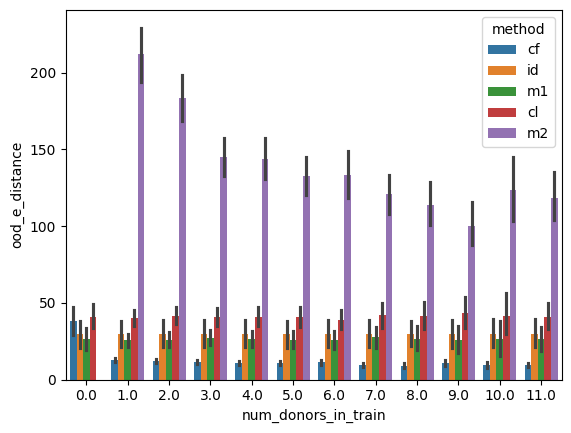

In [16]:
sns.barplot(df, x="num_donors_in_train", y="ood_e_distance", hue="method")

<Axes: xlabel='num_donors_in_train', ylabel='decoded_ood_r_squared'>

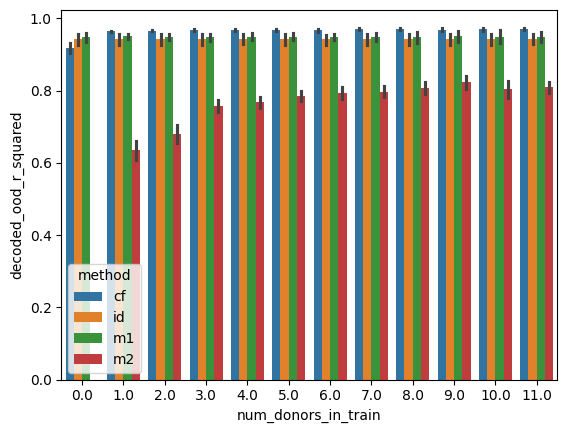

In [14]:
sns.barplot(df, x="num_donors_in_train", y="decoded_ood_r_squared", hue="method")

In [15]:
len(df)

9468

In [18]:
df.head()

,Unnamed: 0,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_mmd_per_cell_type,mean_sdiv_10_per_cell_type,mean_sdiv_100_per_cell_type,mean_deg_r_sq_per_cell_type,mean_deg_e_distance_per_cell_type,mean_deg_mmd_per_cell_type,mean_deg_sdiv_10_per_cell_type,...,deg_e_distance_pDC,deg_mmd_pDC,deg_div_10_pDC,deg_div_100_pDC,donor_cytokine,donor,cytokine,method,donor_cytokine_split-idx,split-idx
0,Donor4_C5a,0.955791,11.660839,0.008871,90.671855,12.128944,0.873296,17.662023,0.040608,125.486287,...,NaN,NaN,NaN,NaN,Donor4_C5a,Donor4,C5a,cf,NaN,NaN
1,Donor7_OX40L,0.922924,35.460599,0.013862,111.972876,25.847652,0.765109,35.802167,0.046710,147.587429,...,NaN,NaN,NaN,NaN,Donor7_OX40L,Donor7,OX40L,cf,NaN,NaN
2,Donor10_C5a,0.948272,16.919249,0.010235,97.359693,15.502340,0.816124,25.159851,0.041936,139.200932,...,NaN,NaN,NaN,NaN,Donor10_C5a,Donor10,C5a,cf,NaN,NaN
3,Donor11_4-1BBL,0.931346,22.054480,0.014290,102.952084,17.665734,0.813616,24.228663,0.046342,151.745742,...,NaN,NaN,NaN,NaN,Donor11_4-1BBL,Donor11,4-1BBL,cf,NaN,NaN
4,Donor6_OSM,0.955859,13.854135,0.007579,96.074269,13.403070,0.880971,18.501366,0.038873,129.942240,...,NaN,NaN,NaN,NaN,Donor6_OSM,Donor6,OSM,cf,NaN,NaN
